In [1]:
import torch
from PIL import Image
import os, json, random
import matplotlib.pyplot as plt
import numpy as np
import gc

from tqdm import tqdm
from safetensors.torch import load_file

from transformers import CLIPTextModel, CLIPTokenizer
from diffusers import AutoencoderKL, UNet2DConditionModel, LMSDiscreteScheduler

from trainscripts.textsliders.lora import (
    LoRANetwork,
    DEFAULT_TARGET_REPLACE,
    UNET_TARGET_REPLACE_MODULE_CONV
)

def flush():
    torch.cuda.empty_cache()
    gc.collect()

@torch.no_grad()
def pil_to_latents(pil_img, vae, device, weight_dtype, height=512, width=512):
    """
    PIL -> VAE latents (SD1.x scaling, latents in model space)
    """
    img = pil_img.convert("RGB").resize((width, height), Image.BICUBIC)
    img = np.array(img).astype(np.float32) / 255.0
    img = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # [1,3,H,W]
    img = img * 2.0 - 1.0
    img = img.to(device=device, dtype=weight_dtype)

    latent_dist = vae.encode(img).latent_dist
    latents = latent_dist.sample()
    latents = latents * 0.18215
    return latents

@torch.no_grad()
def latents_to_pil(latents, vae):
    """
    latents -> PIL (SD1.x scaling)
    """
    latents = latents / 0.18215
    image = vae.decode(latents).sample
    image = (image / 2 + 0.5).clamp(0, 1)
    image = image.detach().cpu().permute(0, 2, 3, 1).numpy()
    image = (image * 255).round().astype("uint8")[0]
    return Image.fromarray(image)

def load_lora_state(path: str):
    if path.endswith(".safetensors"):
        sd = load_file(path, device="cpu")
    else:
        sd = torch.load(path, map_location="cpu")
    if isinstance(sd, dict) and "state_dict" in sd and isinstance(sd["state_dict"], dict):
        sd = sd["state_dict"]
    return sd


/home/sjq/.conda/envs/sliders/lib/python3.9/site-packages/accelerate/utils/torch_xla.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# ---------- basic config ----------
pretrained_model_name_or_path = "CompVis/stable-diffusion-v1-4"
revision = None

device = "cuda:3"
weight_dtype = torch.float16

height = 512
width  = 512

ddim_steps = 50
guidance_scale = 7.5
batch_size = 1

# NOTE:  LMS scheduler
noise_scheduler = LMSDiscreteScheduler(
    beta_start=0.00085, beta_end=0.012, beta_schedule="scaled_linear", num_train_timesteps=1000
)

# ---------- load models ----------
tokenizer = CLIPTokenizer.from_pretrained(pretrained_model_name_or_path, subfolder="tokenizer", revision=revision)
text_encoder = CLIPTextModel.from_pretrained(pretrained_model_name_or_path, subfolder="text_encoder", revision=revision)
vae = AutoencoderKL.from_pretrained(pretrained_model_name_or_path, subfolder="vae", revision=revision)

text_encoder.requires_grad_(False)
vae.requires_grad_(False)

text_encoder.to(device, dtype=weight_dtype)
vae.to(device, dtype=weight_dtype)

flush()
print("Loaded tokenizer/text_encoder/vae.")


Loaded tokenizer/text_encoder/vae.


In [3]:
# path to your LoRA model(s)
lora_weights = [
    # "models/Florence_alpha1.0_rank16_noxattn/Florence_alpha1.0_rank16_noxattn_last.safetensors",
    'models/socalfire_alpha1.0_rank8_noxattn/socalfire_alpha1.0_rank8_noxattn_last.safetensors',
]

# prompt 
prompts = [
    "a high-resolution satellite image, overhead view of a coastal surburb area",
]

# slider scales to test
scales = [0, 0.3, 0.5, 0.8, 1, 1.2, 1.5]

# img2img strengths to test (控制贴近原图程度)
# 0.25~0.45: 更保结构; 0.6+: 变化更大
# strengths = [0.25, 0.35, 0.45]
# strengths = [0.12, 0.18, 0.25]
strengths = [0.7, 0.8, 0.9]
# 输入图片路径
init_image_path = "datasets/Disaster_Recognition_RemoteSense_EN_CN_JA_hub/test/images/socal-fire_00000137_pre_disaster.png"



In [4]:
@torch.no_grad()
def run_one(
    prompt: str,
    negative_prompt: str,      # NEW
    lora_weight_path: str,
    slider_scale: float,       # rename for clarity
    init_pil: Image.Image,
    strength: float,
    seed: int,
):
    if "full" in lora_weight_path:
        train_method = "full"
    elif "noxattn" in lora_weight_path:
        train_method = "noxattn"
    else:
        train_method = "noxattn"

    network_type = "c3lier"
    if train_method == "xattn":
        network_type = "lierla"

    modules = DEFAULT_TARGET_REPLACE
    if network_type == "c3lier":
        modules += UNET_TARGET_REPLACE_MODULE_CONV

    unet = UNet2DConditionModel.from_pretrained(
        pretrained_model_name_or_path, subfolder="unet", revision=revision
    )
    unet.requires_grad_(False)
    unet.to(device, dtype=weight_dtype)

    rank = 16
    alpha = 1.0
    if "rank8" in lora_weight_path:
        rank = 8
    if "alpha1" in lora_weight_path:
        alpha = 1.0

    network = LoRANetwork(
        unet,
        rank=rank,
        multiplier=1.0,
        alpha=alpha,
        train_method=train_method,
    ).to(device, dtype=weight_dtype)

    sd = load_lora_state(lora_weight_path)
    network.load_state_dict(sd, strict=False)

    # ---- text embeddings (CFG) ----
    # cond prompt
    text_input = tokenizer(
        prompt,
        padding="max_length",
        max_length=tokenizer.model_max_length,
        truncation=True,
        return_tensors="pt",
    )
    cond_embeddings = text_encoder(text_input.input_ids.to(device))[0]

    # IMPORTANT: uncond uses NEGATIVE prompt (NOT empty string)
    uncond_input = tokenizer(
        negative_prompt,
        padding="max_length",
        max_length=text_input.input_ids.shape[-1],
        truncation=True,
        return_tensors="pt",
    )
    uncond_embeddings = text_encoder(uncond_input.input_ids.to(device))[0]

    # concat for CFG
    text_embeddings = torch.cat([uncond_embeddings, cond_embeddings], dim=0)

    # ---- img2img init latents ----
    noise_scheduler.set_timesteps(ddim_steps)
    timesteps_all = list(noise_scheduler.timesteps)

    strength = float(strength)
    strength = min(max(strength, 0.0), 0.999)

    t_start = int(len(timesteps_all) * strength)
    t_start = min(max(t_start, 0), len(timesteps_all) - 1)

    init_latents = pil_to_latents(init_pil, vae, device, weight_dtype, height=height, width=width)
    init_latents = init_latents.to(device=device, dtype=weight_dtype)

    torch.manual_seed(seed)
    noise = torch.randn(init_latents.shape, device=init_latents.device, dtype=init_latents.dtype)

    t0 = timesteps_all[t_start]
    if isinstance(t0, torch.Tensor):
        if t0.dim() == 0:
            t0 = t0[None]
        t0 = t0.to(device)
    else:
        t0 = torch.tensor([t0], device=device)
    t0 = t0.repeat(batch_size)

    latents = noise_scheduler.add_noise(init_latents, noise, t0).to(device=device, dtype=weight_dtype)

    # denoise remaining steps
    timesteps = timesteps_all[t_start:]

    # IMPORTANT: slider should be ON from the beginning, with a schedule:
    # early steps: strong injection (semantic change)
    # late steps: reduce to avoid mushy textures
    for i, t in enumerate(timesteps):
        progress = i / max(1, len(timesteps) - 1)
        if progress < 0.6:
            s = float(slider_scale)          # strong early
        else:
            s = float(slider_scale) * 0.6    # weaker late
        network.set_lora_slider(scale=s)

        latent_model_input = torch.cat([latents] * 2)
        latent_model_input = noise_scheduler.scale_model_input(latent_model_input, timestep=t)

        with network:
            noise_pred = unet(latent_model_input, t, encoder_hidden_states=text_embeddings).sample

        noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        latents = noise_scheduler.step(noise_pred, t, latents).prev_sample

    out_pil = latents_to_pil(latents, vae)

    del network, unet
    flush()
    return out_pil


Prompt: orthographic top-down aerial photo, nadir view, remote sensing, map view, realistic, same location, preserve geometry and layout, high resolution, post-disaster wildfire damage, burnt vegetation, charred ground, burn scar patches, ash-gray scorched areas
Seed: 1234
LoRA: models/socalfire_alpha1.0_rank8_noxattn/socalfire_alpha1.0_rank8_noxattn_last.safetensors
create LoRA for U-Net: 150 modules.


OutOfMemoryError: CUDA out of memory. Tried to allocate 64.00 MiB (GPU 3; 23.64 GiB total capacity; 2.03 GiB already allocated; 45.88 MiB free; 2.09 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

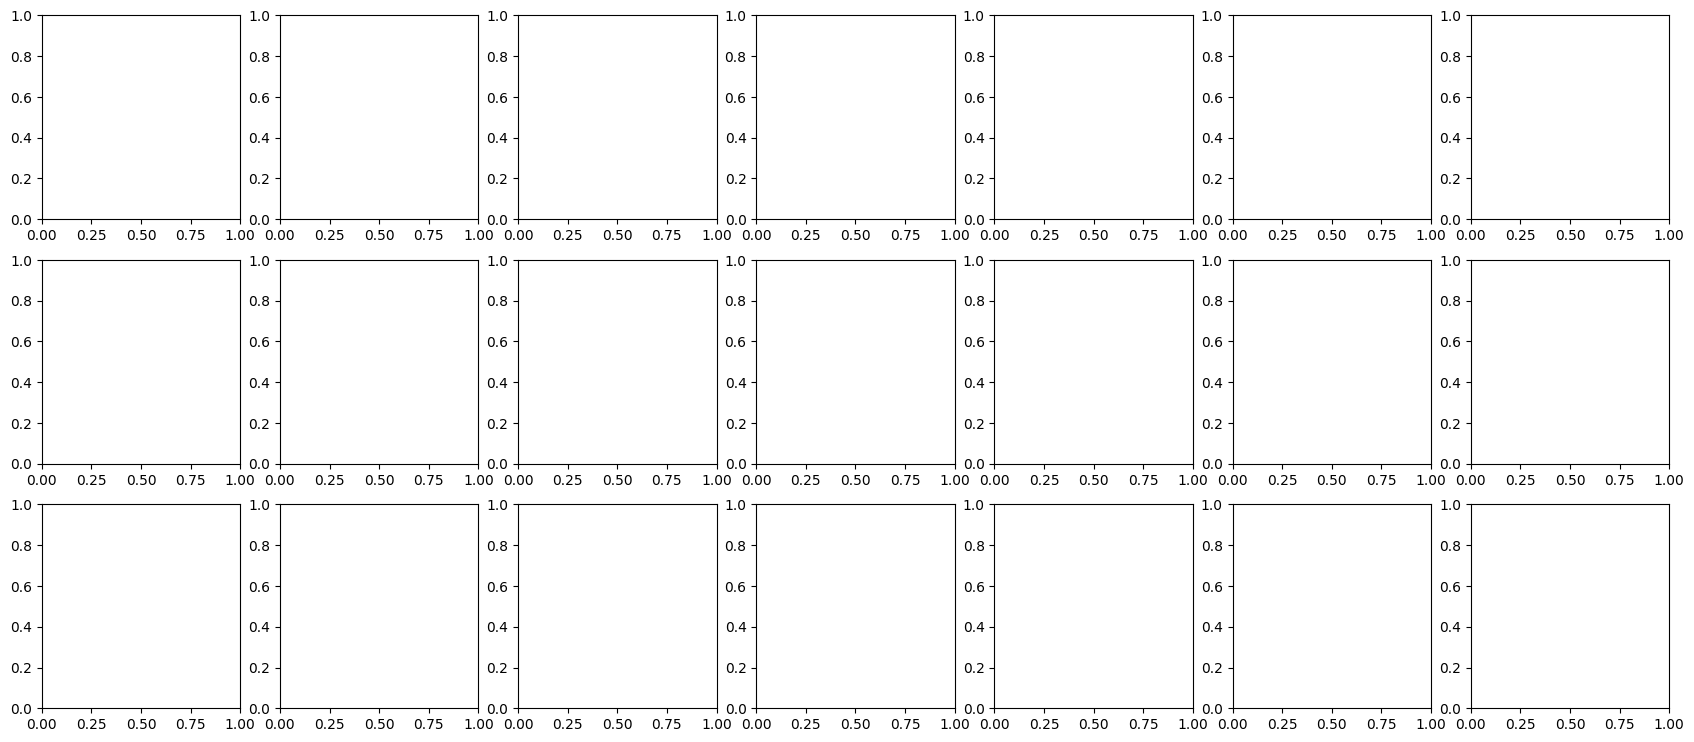

In [5]:
# =========================
# JUPYTER CELL: prompt + negative + run grid
# =========================

# --- make sure slider_scales exists ---
if "slider_scales" not in globals():
    if "scales" in globals():
        slider_scales = scales
    else:
        slider_scales = [0, 0.3, 0.5, 0.8, 1.0, 1.2, 1.5]

# ===== Prompt bases =====
POS_BASE = (
    "orthographic top-down aerial photo, nadir view, remote sensing, map view, "
    "realistic, same location, preserve geometry and layout, high resolution"
)

NEG_PROMPT = (
    "horizon, sky, atmosphere, planet curvature, earth from space, globe, "
    "tilted view, fisheye, wide angle, cinematic, "
    "cartoon, anime, illustration, painting, CGI, unreal engine, "
    "text, watermark, logo, frame, border, caption, "
    "swirl patterns, wavy artifacts, hallucinated textures, melted terrain"
)

prompts = [
    f"{POS_BASE}, post-disaster wildfire damage, burnt vegetation, charred ground, burn scar patches, ash-gray scorched areas",
]

PRE_DISASTER_HINT = "pre-disaster, undamaged, no visible damage"

# ===== Load init image once =====
assert os.path.exists(init_image_path), f"init_image_path not found: {init_image_path}"
init_pil = Image.open(init_image_path)

# ===== Run grid =====
BASE_SEED = 1234

for p_idx, prompt in enumerate(prompts):
    seed = BASE_SEED + p_idx
    print("Prompt:", prompt)
    print("Seed:", seed)

    for lora_weight in lora_weights:
        print("LoRA:", lora_weight)

        fig, axes = plt.subplots(
            len(strengths), len(slider_scales),
            figsize=(3 * len(slider_scales), 3 * len(strengths))
        )
        if len(strengths) == 1:
            axes = np.expand_dims(axes, axis=0)
        if len(slider_scales) == 1:
            axes = np.expand_dims(axes, axis=1)

        for r, strength in enumerate(strengths):
            for c, slider_scale in enumerate(slider_scales):
                # optional: make slider=0 look more like pre-disaster
                if slider_scale == 0:
                    use_prompt = f"{POS_BASE}, {PRE_DISASTER_HINT}"
                else:
                    use_prompt = prompt

                out = run_one(
                    prompt=use_prompt,
                    negative_prompt=NEG_PROMPT,
                    lora_weight_path=lora_weight,
                    slider_scale=slider_scale,
                    init_pil=init_pil,
                    strength=strength,
                    seed=seed
                )

                ax = axes[r, c]
                ax.imshow(out)
                ax.axis("off")
                ax.set_title(f"str={strength}, slider={slider_scale}", fontsize=10)

        plt.tight_layout()
        plt.show()
